In [2]:
import sys
import os
import torch
import numpy as np
from pathlib import Path
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import math
current_dir = Path(os.getcwd())
project_root = current_dir.parent
sys.path.append(str(project_root))

from src.train.model import Generator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
model_path = "outputs/checkpoints/checkpoint_epoch_35.pth"

model = Generator(upscale_factor=2).to(device)

try:
    checkpoint = torch.load(model_path, map_location=device)
    if 'G_state' in checkpoint:
        model.load_state_dict(checkpoint['G_state'])
    else:
        model.load_state_dict(checkpoint)
    print("Model loaded successfully")
except Exception as e:
    print(f"Error loading model: {e}")

model.eval()

Error loading model: [Errno 2] No such file or directory: 'outputs/checkpoints/checkpoint_epoch_35.pth'


Generator(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (prelu): PReLU(num_parameters=1)
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (prelu): PReLU(num_parameters=1)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (prelu): PReLU(num_parameters=1)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): Residua

In [4]:
def advanced_inference_tta(model, lr_img_tensor, device="cuda"):
    model.eval()
    outputs = []
    
    # =========================================================================
    # [INSIGHT 3] REFLECTIVE PADDING (Boundary Handling)
    # Menambah padding dengan memantulkan tepi gambar untuk mengatasi 
    # border artifacts (pinggiran hitam/aneh) akibat konvolusi.
    # =========================================================================
    pad_size = 16
    lr_img_padded = F.pad(lr_img_tensor, (pad_size, pad_size, pad_size, pad_size), mode='reflect')
    
    with torch.no_grad():
        # =====================================================================
        # [INSIGHT 1] GEOMETRIC INVARIANCE (Rotasi & Flip)
        # Memanfaatkan 8 variasi sudut pandang untuk menghilangkan bias posisi
        # dan artifak yang muncul pada orientasi tertentu.
        # =====================================================================
        for i in range(8):
            img_aug = lr_img_padded.clone()
            
            # --- Fase Augmentasi (Input Transformation) ---
            if i == 0: pass 
            elif i == 1: img_aug = TF.rotate(img_aug, 90)
            elif i == 2: img_aug = TF.rotate(img_aug, 180)
            elif i == 3: img_aug = TF.rotate(img_aug, 270)
            elif i == 4: img_aug = TF.vflip(img_aug)
            elif i == 5: img_aug = TF.rotate(TF.vflip(img_aug), 90)
            elif i == 6: img_aug = TF.rotate(TF.vflip(img_aug), 180)
            elif i == 7: img_aug = TF.rotate(TF.vflip(img_aug), 270)
            
            # --- Prediksi Model ---
            out_aug = model(img_aug.to(device))
            
            # --- Fase Inverse (Kembalikan ke Posisi Semula) ---
            if i == 0: pass
            elif i == 1: out_aug = TF.rotate(out_aug, -90)
            elif i == 2: out_aug = TF.rotate(out_aug, -180)
            elif i == 3: out_aug = TF.rotate(out_aug, -270)
            elif i == 4: out_aug = TF.vflip(out_aug)
            elif i == 5: out_aug = TF.vflip(TF.rotate(out_aug, -90))
            elif i == 6: out_aug = TF.vflip(TF.rotate(out_aug, -180))
            elif i == 7: out_aug = TF.vflip(TF.rotate(out_aug, -270))
            
            # Potong Padding (Un-padding)
            scale = 2
            pad_hr = pad_size * scale
            out_cropped = out_aug[..., pad_hr:-pad_hr, pad_hr:-pad_hr]
            
            outputs.append(out_cropped)
    
    # =========================================================================
    # [INSIGHT 2] STATISTICAL AGGREGATION (Ensemble Averaging)
    # Merata-ratakan hasil prediksi untuk menghilangkan noise stokastik 
    # dan memperkuat detail struktur yang konsisten.
    # =========================================================================
    final_output = torch.stack(outputs).mean(dim=0)
    
    return final_output

In [5]:
def calculate_psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0: return 100
    pixel_max = 1.0
    return 20 * math.log10(pixel_max / math.sqrt(mse))

def tensor_to_image(tensor):
    tensor = tensor.cpu().squeeze(0).detach()
    tensor = (tensor + 1) / 2
    tensor = tensor.clamp(0, 1)
    return tensor.permute(1, 2, 0).numpy()

Menggunakan gambar: ..\data\custom\Set5\butterfly.png
Ukuran Input (LR): (128, 128)
Ukuran Target (HR): (256, 256)
------------------------------
PSNR Standard : 5.32 dB
PSNR Improved : 8.30 dB
Peningkatan   : +2.98 dB
------------------------------


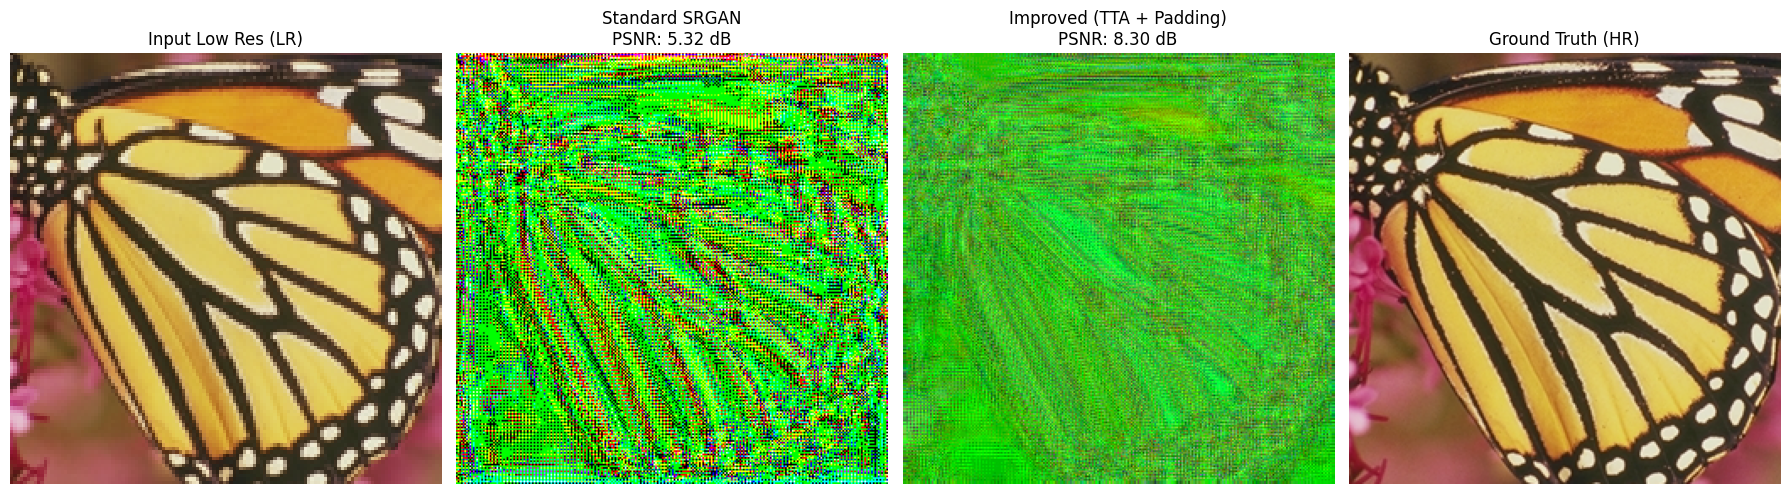

In [ ]:
img_name = "butterfly.png" 
hr_path_full = os.path.join("..","data", "custom", "Set5", img_name)

if not os.path.exists(hr_path_full):
    print(f"File tidak ditemukan: {hr_path_full}")
    print("Mencoba mencari di folder lain...")
    hr_path_full = "butterfly.png" 
else:
    print(f"Menggunakan gambar: {hr_path_full}")

hr_pil = Image.open(hr_path_full).convert('RGB')
w, h = hr_pil.size

w_new = w - (w % 2)
h_new = h - (h % 2)
hr_pil = hr_pil.crop((0, 0, w_new, h_new))

lr_pil = hr_pil.resize((w_new // 2, h_new // 2), Image.BICUBIC)

lr_tensor = transforms.ToTensor()(lr_pil).unsqueeze(0).to(device)
lr_tensor = (lr_tensor * 2) - 1

hr_np = np.array(hr_pil).astype(np.float32) / 255.0

print(f"Ukuran Input (LR): {lr_pil.size}")
print(f"Ukuran Target (HR): {hr_pil.size}")

with torch.no_grad():
    sr_old = model(lr_tensor)
sr_old_img = tensor_to_image(sr_old)

sr_new = advanced_inference_tta(model, lr_tensor, device)
sr_new_img = tensor_to_image(sr_new)

h_t, w_t, _ = hr_np.shape
sr_old_img = sr_old_img[:h_t, :w_t, :]
sr_new_img = sr_new_img[:h_t, :w_t, :]

psnr_old = calculate_psnr(hr_np, sr_old_img)
psnr_new = calculate_psnr(hr_np, sr_new_img)

print("-" * 30)
print(f"PSNR Standard : {psnr_old:.2f} dB")
print(f"PSNR Improved : {psnr_new:.2f} dB")
print(f"Peningkatan   : +{psnr_new - psnr_old:.2f} dB")
print("-" * 30)

plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.title("Input Low Res (LR)")
plt.imshow(lr_pil)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title(f"Standard SRGAN\nPSNR: {psnr_old:.2f} dB")
plt.imshow(sr_old_img)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title(f"Improved (TTA + Padding)\nPSNR: {psnr_new:.2f} dB")
plt.imshow(sr_new_img)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Ground Truth (HR)")
plt.imshow(hr_np)
plt.axis('off')

plt.tight_layout()
plt.show()